# 01 — Data Preparation (Exon 4-15 Strategy)

===========================================
Parse tBLASTn results for MROH6 in the zebra finch genome using two protein
queries combined with exon 13 BLASTn anchors. Apply Tony's exon 4-15 strategy:
filter for gene units with >=50% coverage of the exon 4-15 region to produce
a clean codon alignment for dN/dS analysis.

Strategy change (March 2026):
  OLD: Use all exons, 300bp length filter → 411 gene units, noisy alignment
  NEW: Exon 4-15 focus, 50% coverage filter → cleaner alignment for PAML

Usage:
  python notebooks/01_data_prep.py

In [1]:
import sys
from pathlib import Path

# Jupyter-compatible project root detection
# Works whether you launch from project root or notebooks/ directory
_cwd = Path.cwd()
PROJECT = _cwd if (_cwd / 'scripts').exists() else _cwd.parent
sys.path.insert(0, str(PROJECT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import subprocess

from utils import (
    parse_blast_fasta, parse_exon13_blastn, parse_combined_tblastn,
    build_accession_to_chrom, define_gene_units, gene_units_to_fasta,
    merge_overlapping_hits, define_gene_units_from_anchors_only,
    EXON4_15_LEN_NT, EXON4_START_AA, EXON15_END_AA
)
from species_config import load_config, resolve_path, get_data_dirs, classify_chrom

# ── SPECIES CONFIGURATION ──
# Change this to run a different species:
SPECIES_SLUG = "zebra_finch"  # or "melospiza_georgiana"

cfg = load_config(SPECIES_SLUG)
dirs = get_data_dirs(cfg)

DATA_PROC = dirs["data_proc"]
FIG_DIR = dirs["fig_dir"]
TABLE_DIR = dirs["table_dir"]

sns.set_context('notebook')
sns.set_style('whitegrid')

MIN_COVERAGE = cfg["min_coverage"]
GENE = cfg["gene_name"]
SPECIES = cfg["common_name"]
prefix = cfg["output_prefix"]

print(f"Species: {cfg['species_name']} ({SPECIES})")
print(f"Gene: {GENE}")
print(f"Genome: {cfg['genome_assembly']} ({cfg['genome_accession']})")
print(f"Output prefix: {prefix}")
print(f"Data dir: {DATA_PROC}")
print(f"Figures dir: {FIG_DIR}")

Species: Taeniopygia guttata (Zebra finch)
Gene: MROH6
Genome: bTaeGut7.mat (GCF_003957565.2)
Output prefix: mroh6_zebra_finch
Data dir: /Users/makuachtenygatluak/Documents/Research/data/processed/zebra_finch
Figures dir: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures


## Summary

In [2]:
print("=" * 70)
print("  STEP 01: DATA PREPARATION — Exon 4-15 Strategy")

  STEP 01: DATA PREPARATION — Exon 4-15 Strategy


## Summary

In [3]:
print("=" * 70)

## 1a. Parse inputs

## 1a. Parsing exon 13 anchors and tBLASTn hits

In [4]:
# ── 1a. Parse exon 13 anchors ──
# The 23-mer probe from exon 13 is highly conserved across all MROH copies.
# Each BLASTn hit = one gene copy. This gives copy count and genomic positions.
anchor_path = resolve_path(cfg, cfg["exon13_anchor_file"])
anchor_fmt = cfg.get("exon13_anchor_format", "auto")
exon13 = parse_exon13_blastn(anchor_path, fmt=anchor_fmt)
print(f"Exon 13 anchors: {len(exon13)} across {exon13['saccver'].nunique()} accessions")

# Build accession -> chromosome mapping
if anchor_fmt == "fasta":
    anchor_fasta_df = parse_blast_fasta(anchor_path)
    acc_to_chrom_anchor = build_accession_to_chrom(anchor_fasta_df)
else:
    acc_to_chrom_anchor = {}

# ── 1b. Parse tBLASTn hits ──
# tBLASTn gives actual nucleotide sequences for each copy (needed for alignment + dN/dS)
tblastn_paths = [resolve_path(cfg, f) for f in cfg["tblastn_files"]]
existing_tblastn = [p for p in tblastn_paths if p.exists()]

if existing_tblastn:
    tblastn = parse_combined_tblastn(existing_tblastn)
    acc_to_chrom = build_accession_to_chrom(tblastn)
    acc_to_chrom.update({k: v for k, v in acc_to_chrom_anchor.items() if k not in acc_to_chrom})
    print(f"tBLASTn hits (combined, deduplicated): {len(tblastn)}")
    has_tblastn = True
else:
    print("WARNING: No tBLASTn files found. Proceeding with anchor-only analysis.")
    for p in tblastn_paths:
        print(f"  Expected: {p}")
    tblastn = pd.DataFrame()
    acc_to_chrom = acc_to_chrom_anchor
    has_tblastn = False

# Chromosome distribution
anchor_chroms = exon13['saccver'].map(acc_to_chrom).fillna('unknown')
print(f"\nTotal {GENE} copies (by exon 13 count): {len(exon13)}")
print(f"\nAnchor distribution by chromosome:")
for chrom, count in anchor_chroms.value_counts().head(15).items():
    print(f"  chr {chrom}: {count} anchors")

Exon 13 anchors: 411 across 21 accessions
tBLASTn hits (combined, deduplicated): 3471

Total MROH6 copies (by exon 13 count): 411

Anchor distribution by chromosome:
  chr 16: 85 anchors
  chr 25: 52 anchors
  chr 35: 48 anchors
  chr 30: 36 anchors
  chr 29: 35 anchors
  chr 31: 31 anchors
  chr 33: 24 anchors
  chr 34: 24 anchors
  chr 37: 22 anchors
  chr 36: 13 anchors
  chr 32: 10 anchors
  chr 7: 9 anchors
  chr 6: 7 anchors
  chr 28: 4 anchors
  chr 24: 3 anchors


## Figure 1: BLAST hit overview

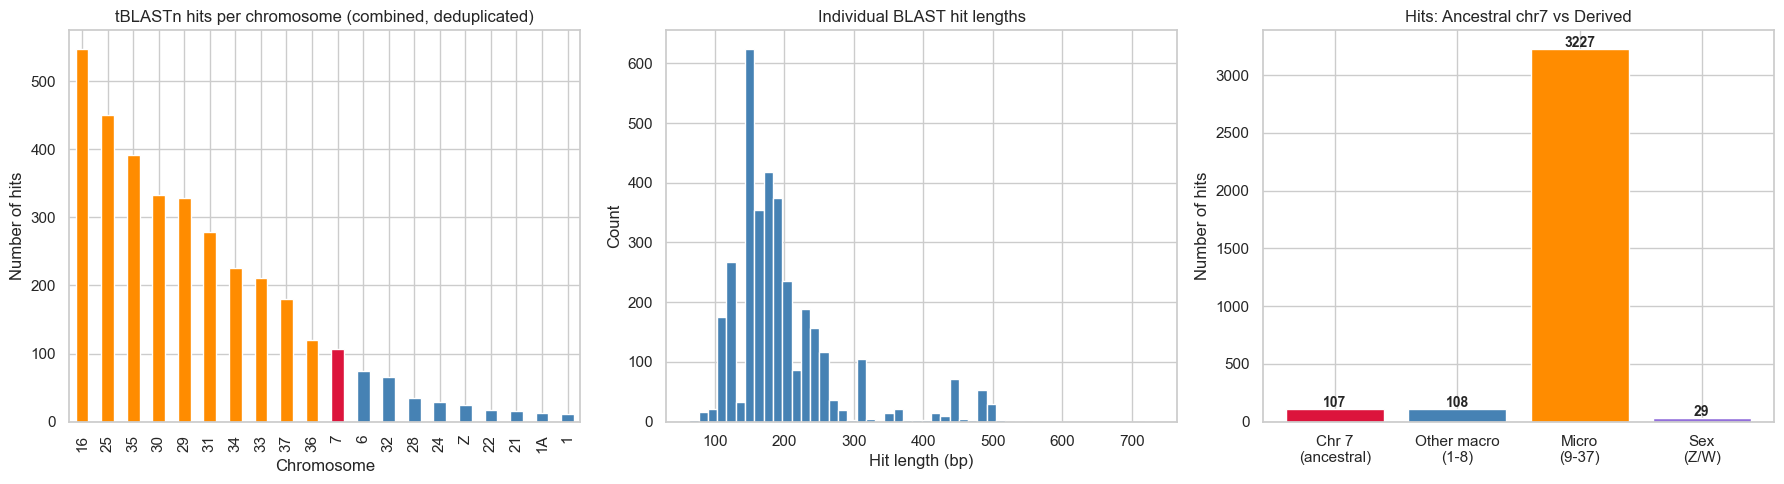

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/blast_hit_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

chrom_counts = tblastn['chrom'].value_counts().head(20)
colors = ['crimson' if c == '7' else ('darkorange' if c in ['16','25','29','30','31','33','34','35','36','37'] else 'steelblue')
          for c in chrom_counts.index]
chrom_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('tBLASTn hits per chromosome (combined, deduplicated)')
axes[0].set_xlabel('Chromosome')
axes[0].set_ylabel('Number of hits')

axes[1].hist(tblastn['seq_len'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Individual BLAST hit lengths')
axes[1].set_xlabel('Hit length (bp)')
axes[1].set_ylabel('Count')

macro_chroms = ['1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8']
micro_chroms = [c for c in tblastn['chrom'].unique()
                if c not in macro_chroms and c not in ['Z', 'W', 'unknown']]
cats = {
    'Chr 7\n(ancestral)': len(tblastn[tblastn['chrom'] == '7']),
    'Other macro\n(1-8)': len(tblastn[(tblastn['chrom'].isin(macro_chroms)) & (tblastn['chrom'] != '7')]),
    'Micro\n(9-37)': len(tblastn[tblastn['chrom'].isin(micro_chroms)]),
    'Sex\n(Z/W)': len(tblastn[tblastn['chrom'].isin(['Z', 'W'])]),
}
axes[2].bar(cats.keys(), cats.values(),
            color=['crimson', 'steelblue', 'darkorange', 'mediumpurple'])
axes[2].set_title('Hits: Ancestral chr7 vs Derived')
axes[2].set_ylabel('Number of hits')
for i, (k, v) in enumerate(cats.items()):
    axes[2].text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'blast_hit_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'blast_hit_overview.png'}")

## 1b. Define gene units with exon 4-15 coverage filter

In [6]:
# ── 1c. Define gene units with coverage filter ──
# Merge tBLASTn hits into "gene units" (one per copy) using exon 13 anchors.
# Apply coverage filter: only keep copies with >=50% of expected CDS length.
# Decision tree: try primary exon range first, fall back if too few pass.

primary_range = cfg["analysis_exon_range"]
primary_len_nt = cfg["analysis_len_nt"]
primary_label = f"exons {primary_range[0]}-{primary_range[1]}"

print(f"Strategy: {primary_label}, {MIN_COVERAGE*100:.0f}% coverage filter")
print(f"Expected CDS length: {primary_len_nt} nt")
print(f"Minimum sequence length: {int(primary_len_nt * MIN_COVERAGE)} nt")

if has_tblastn:
    gu_all, gu_filtered = define_gene_units(
        exon13, tblastn, acc_to_chrom,
        expected_len_nt=primary_len_nt,
        max_dist=cfg["max_anchor_dist"],
        merge_gap=cfg["merge_gap"],
        min_coverage=MIN_COVERAGE
    )
else:
    gu_all = define_gene_units_from_anchors_only(exon13, acc_to_chrom)
    gu_filtered = gu_all.copy()

# Classify chromosomes using species config
gu_all['chrom_class'] = gu_all['chrom'].apply(lambda c: classify_chrom(c, cfg))
gu_filtered['chrom_class'] = gu_filtered['chrom'].apply(lambda c: classify_chrom(c, cfg))

# Decision tree: fall back to narrower exon range if too few units pass
fallback_range = cfg.get("fallback_exon_range")
used_fallback = False

if has_tblastn and fallback_range and len(gu_filtered) < cfg.get("min_gene_units_for_paml", 15):
    print(f"\n*** Only {len(gu_filtered)} gene units passed with {primary_label}.")
    print(f"*** Falling back to exons {fallback_range[0]}-{fallback_range[1]}...")
    fallback_len_nt = cfg["fallback_len_nt"]
    gu_all, gu_filtered = define_gene_units(
        exon13, tblastn, acc_to_chrom,
        expected_len_nt=fallback_len_nt,
        max_dist=cfg["max_anchor_dist"],
        merge_gap=cfg["merge_gap"],
        min_coverage=MIN_COVERAGE
    )
    gu_all['chrom_class'] = gu_all['chrom'].apply(lambda c: classify_chrom(c, cfg))
    gu_filtered['chrom_class'] = gu_filtered['chrom'].apply(lambda c: classify_chrom(c, cfg))
    used_fallback = True

# Identify ancestral copy
anc_chr = cfg["ancestral_chromosome"]
anc_range = cfg.get("ancestral_locus_range")
if anc_range:
    chr_gu = gu_filtered[(gu_filtered['chrom'] == anc_chr) &
                          (gu_filtered['start'] > anc_range[0]) &
                          (gu_filtered['end'] < anc_range[1])]
else:
    chr_gu = gu_filtered[gu_filtered['chrom'] == anc_chr]

if len(chr_gu) > 0:
    if has_tblastn:
        ancestral_idx = chr_gu['total_seq_len'].idxmax()
    else:
        ancestral_idx = chr_gu.index[0]
    ancestral_id = gu_filtered.loc[ancestral_idx, 'gene_unit_id']
    gu_filtered['is_ancestral'] = gu_filtered['gene_unit_id'] == ancestral_id
    gu_all['is_ancestral'] = gu_all['gene_unit_id'] == ancestral_id
    print(f"Ancestral copy: gu_{ancestral_id} (chr{anc_chr})")
else:
    gu_filtered['is_ancestral'] = False
    gu_all['is_ancestral'] = False
    print(f"WARNING: Could not identify ancestral locus on chr{anc_chr}")

print(f"\nGene units defined: {len(gu_all)}")
if has_tblastn:
    print(f"After {MIN_COVERAGE*100:.0f}% coverage filter: {len(gu_filtered)} gene units")
    print(f"Removed: {len(gu_all) - len(gu_filtered)} (insufficient coverage)")
print(f"\nChromosome classification:")
print(gu_filtered['chrom_class'].value_counts().to_string())

Strategy: exons 4-15, 50% coverage filter
Expected CDS length: 1641 nt
Minimum sequence length: 820 nt
Ancestral copy: gu_17 (chr7)

Gene units defined: 419
After 50% coverage filter: 399 gene units
Removed: 20 (insufficient coverage)

Chromosome classification:
chrom_class
micro_derived     378
macro_derived      10
chr7_ancestral      8
sex_chrom           3


## Figure 2: Coverage filter visualization

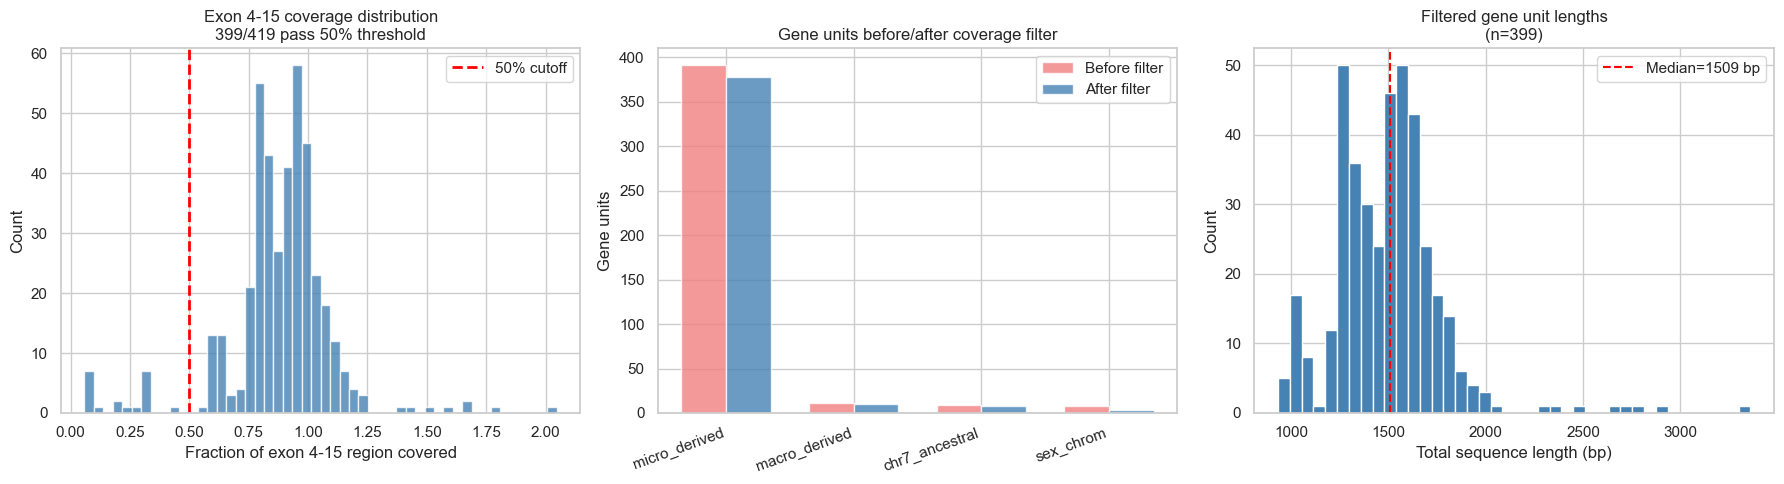

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/exon4_15_coverage_filter.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coverage distribution
ax = axes[0]
cov = gu_all['coverage_frac']
ax.hist(cov[cov > 0], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(MIN_COVERAGE, color='red', linestyle='--', linewidth=2,
           label=f'{MIN_COVERAGE*100:.0f}% cutoff')
n_pass = (cov >= MIN_COVERAGE).sum()
n_total = (cov > 0).sum()
ax.set_title(f'Exon 4-15 coverage distribution\n'
             f'{n_pass}/{n_total} pass {MIN_COVERAGE*100:.0f}% threshold')
ax.set_xlabel('Fraction of exon 4-15 region covered')
ax.set_ylabel('Count')
ax.legend()

# Before vs after filter
ax = axes[1]
before_class = gu_all[gu_all['total_seq_len'] > 0]['chrom_class'].value_counts()
after_class = gu_filtered['chrom_class'].value_counts()
x = range(len(before_class))
w = 0.35
ax.bar([i - w/2 for i in x], before_class.values, w,
       label='Before filter', color='lightcoral', alpha=0.8)
after_vals = [after_class.get(c, 0) for c in before_class.index]
ax.bar([i + w/2 for i in x], after_vals, w,
       label='After filter', color='steelblue', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(before_class.index, rotation=20, ha='right')
ax.set_ylabel('Gene units')
ax.set_title('Gene units before/after coverage filter')
ax.legend()

# Sequence length distribution (filtered)
ax = axes[2]
ax.hist(gu_filtered['total_seq_len'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Total sequence length (bp)')
ax.set_ylabel('Count')
ax.set_title(f'Filtered gene unit lengths\n(n={len(gu_filtered)})')
ax.axvline(gu_filtered['total_seq_len'].median(), color='red', linestyle='--',
           label=f"Median={gu_filtered['total_seq_len'].median():.0f} bp")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'exon4_15_coverage_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'exon4_15_coverage_filter.png'}")

## Figure 3: Exon 13 anchor quality

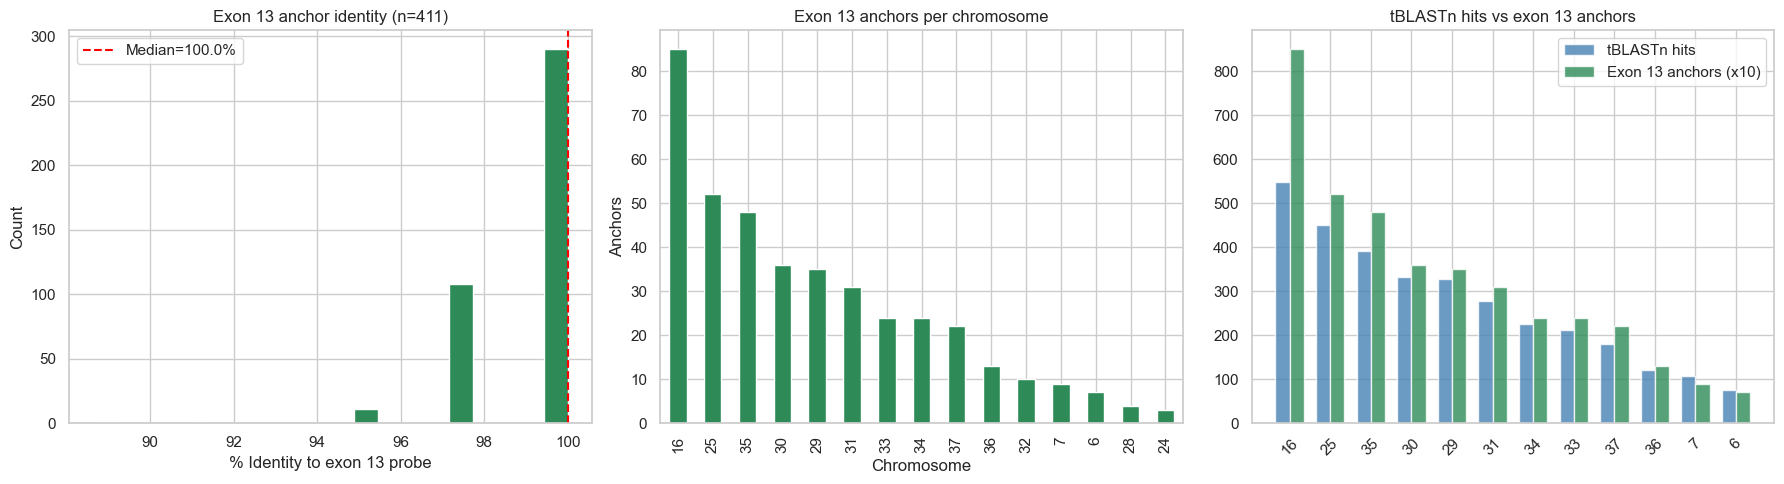

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/exon13_anchor_quality.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(exon13['pident'], bins=20, color='seagreen', edgecolor='white')
ax.set_xlabel('% Identity to exon 13 probe')
ax.set_ylabel('Count')
ax.set_title(f'Exon 13 anchor identity (n={len(exon13)})')
ax.axvline(exon13['pident'].median(), color='red', linestyle='--',
           label=f'Median={exon13["pident"].median():.1f}%')
ax.legend()

ax = axes[1]
exon13_chroms = exon13['saccver'].map(acc_to_chrom).fillna('unknown')
chrom_counts_e13 = exon13_chroms.value_counts().head(15)
chrom_counts_e13.plot.bar(ax=ax, color='seagreen')
ax.set_title('Exon 13 anchors per chromosome')
ax.set_xlabel('Chromosome')
ax.set_ylabel('Anchors')

ax = axes[2]
blast_by_chrom = tblastn['chrom'].value_counts()
e13_by_chrom = exon13_chroms.value_counts()
compare_chroms = blast_by_chrom.head(12).index
x = range(len(compare_chroms))
w = 0.35
ax.bar([i - w/2 for i in x],
       [blast_by_chrom.get(c, 0) for c in compare_chroms],
       w, label='tBLASTn hits', color='steelblue', alpha=0.8)
ax.bar([i + w/2 for i in x],
       [e13_by_chrom.get(c, 0) * 10 for c in compare_chroms],
       w, label='Exon 13 anchors (x10)', color='seagreen', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(compare_chroms, rotation=45)
ax.set_title('tBLASTn hits vs exon 13 anchors')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'exon13_anchor_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'exon13_anchor_quality.png'}")

## Figure 4: Genomic distribution

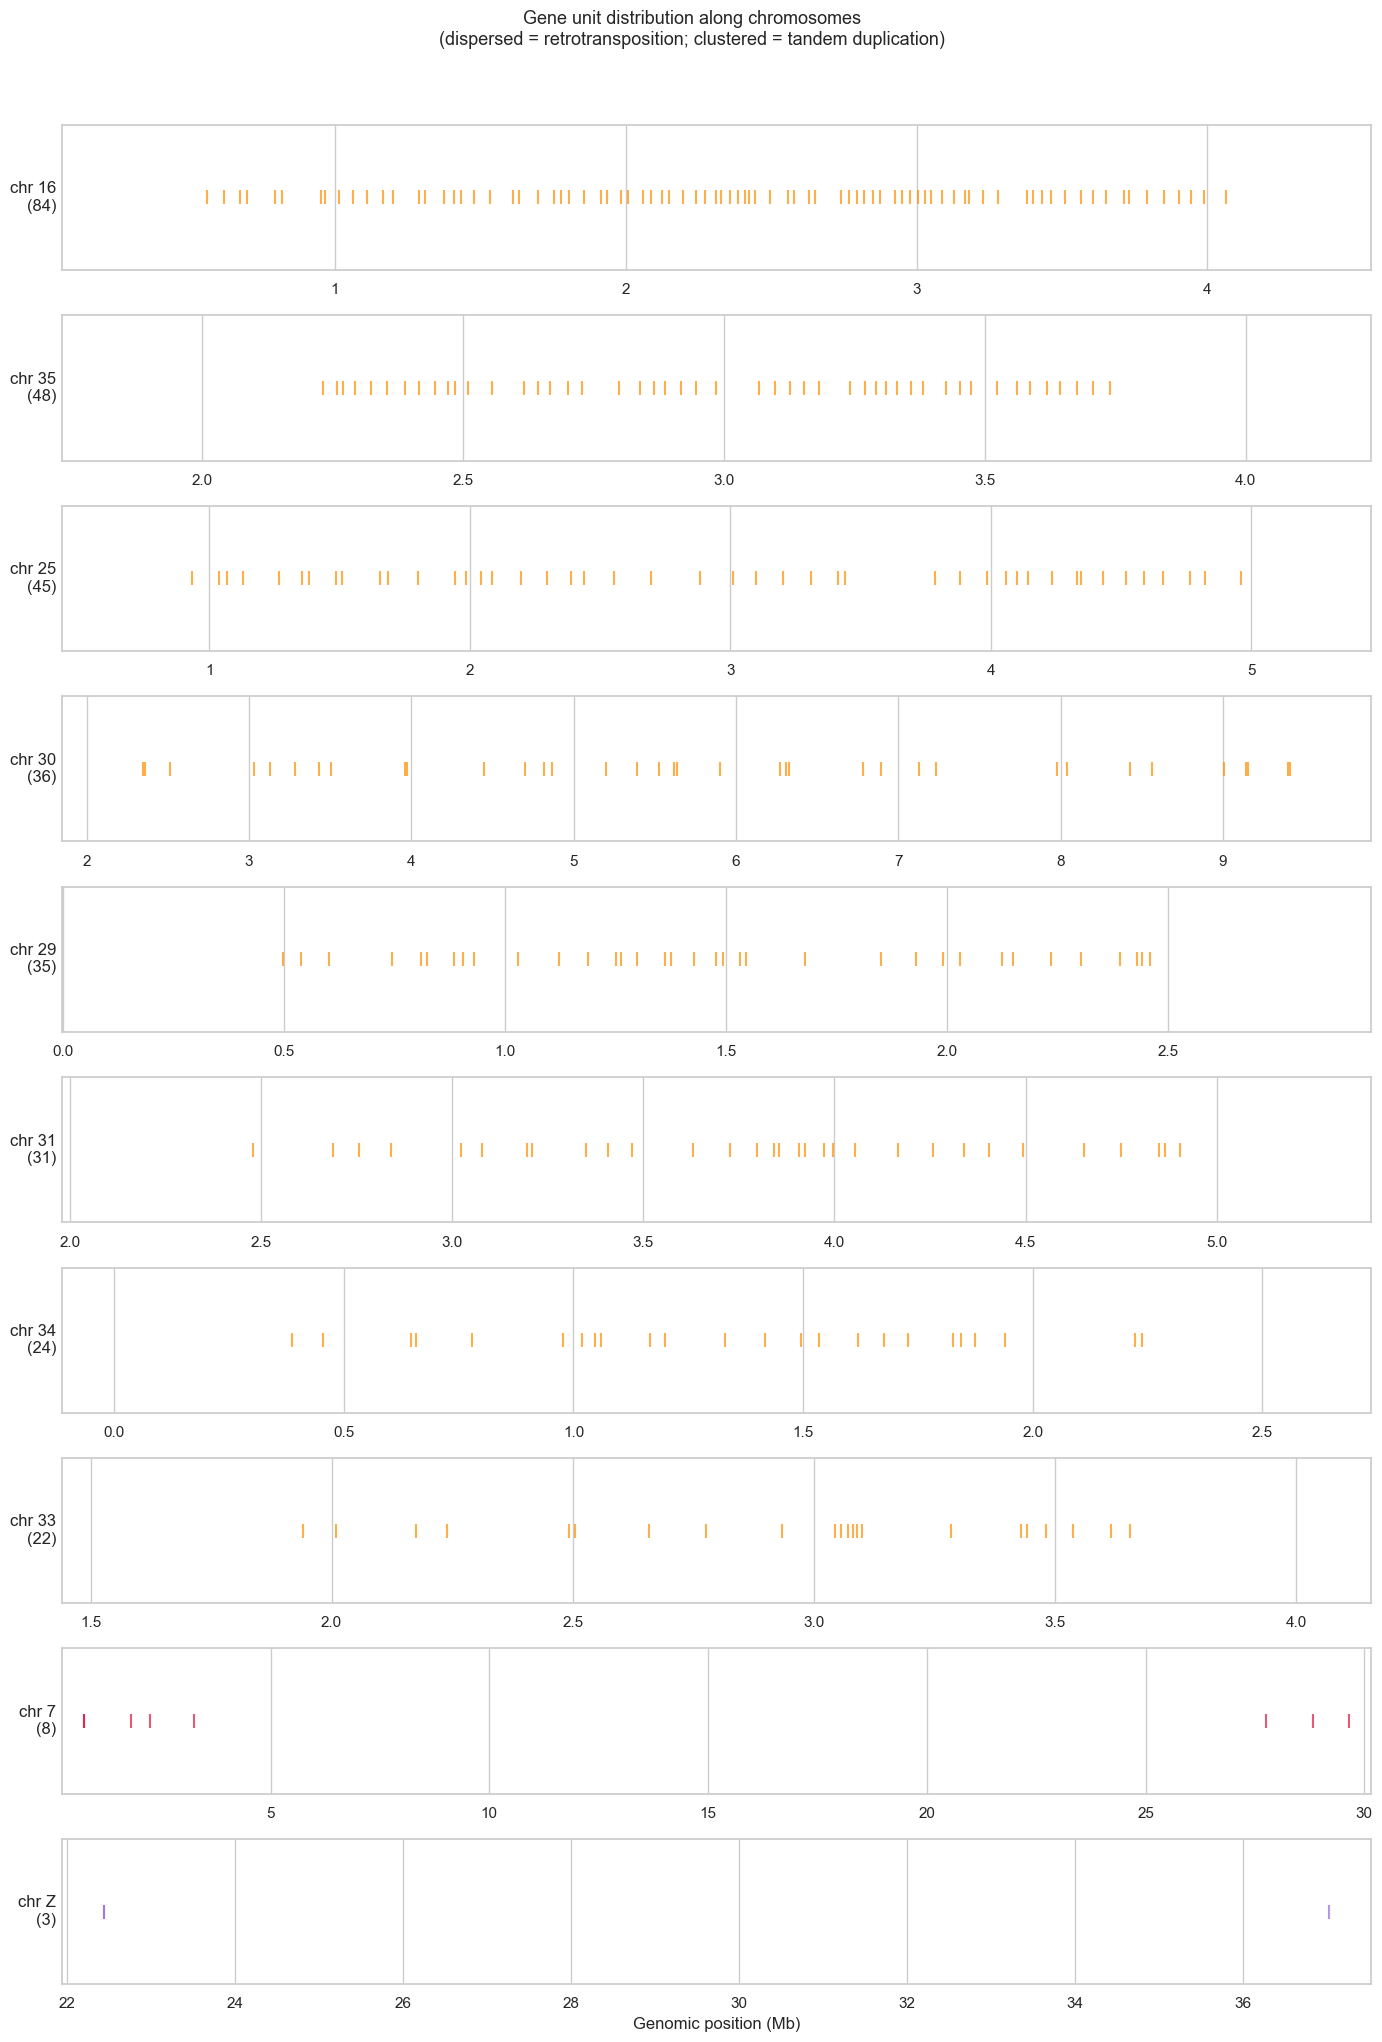

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/gene_unit_genomic_distribution.png


In [9]:
top_chroms = gu_filtered['chrom'].value_counts().head(8).index.tolist()
for c in ['7', 'Z']:
    if c not in top_chroms and c in gu_filtered['chrom'].values:
        top_chroms.append(c)

fig, axes = plt.subplots(len(top_chroms), 1,
                         figsize=(14, 2 * len(top_chroms)), sharex=False)
if len(top_chroms) == 1:
    axes = [axes]

for ax, chrom in zip(axes, top_chroms):
    chrom_gu = gu_filtered[gu_filtered['chrom'] == chrom]
    positions = chrom_gu['start'].values / 1e6
    color = 'crimson' if chrom == '7' else ('mediumpurple' if chrom == 'Z' else 'darkorange')
    ax.scatter(positions, [1]*len(positions), marker='|', s=100, color=color, alpha=0.7)
    ax.set_yticks([])
    ax.set_ylabel(f'chr {chrom}\n({len(chrom_gu)})', rotation=0, ha='right', va='center')
    if len(positions) > 0:
        ax.set_xlim(positions.min() - 0.5, positions.max() + 0.5)

axes[-1].set_xlabel('Genomic position (Mb)')
fig.suptitle('Gene unit distribution along chromosomes\n'
             '(dispersed = retrotransposition; clustered = tandem duplication)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gene_unit_genomic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'gene_unit_genomic_distribution.png'}")

## Figure 5: Hits per gene unit + coverage scatter

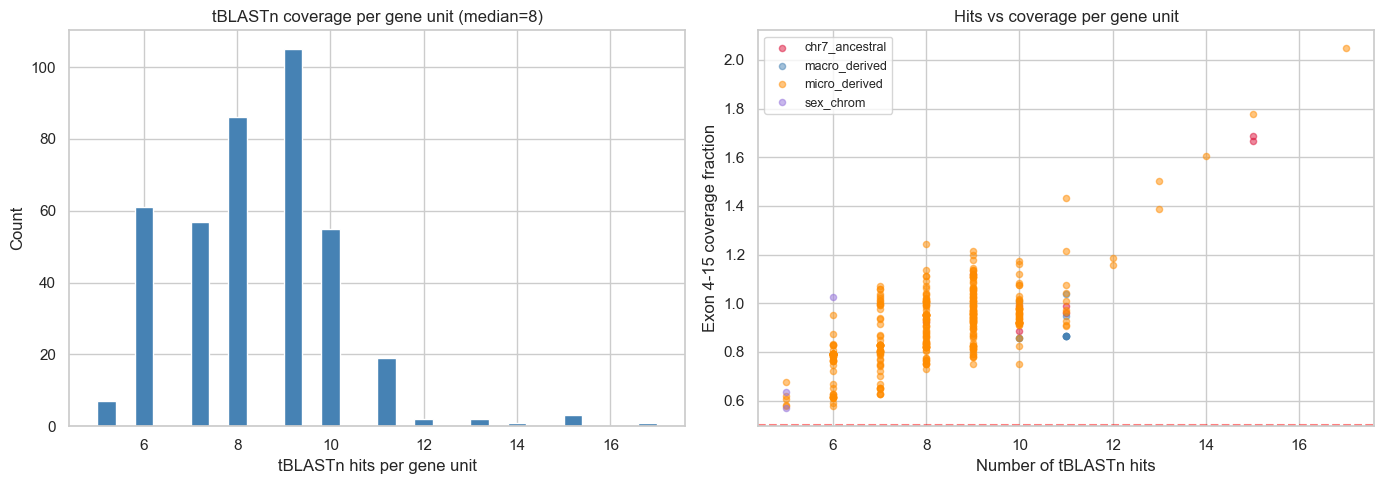

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/gene_unit_coverage.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(gu_filtered['n_hits'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('tBLASTn hits per gene unit')
ax.set_ylabel('Count')
ax.set_title(f'tBLASTn coverage per gene unit (median={gu_filtered["n_hits"].median():.0f})')

ax = axes[1]
color_map = {'chr7_ancestral': 'crimson', 'macro_derived': 'steelblue',
             'micro_derived': 'darkorange', 'sex_chrom': 'mediumpurple'}
for cls, color in color_map.items():
    mask = gu_filtered['chrom_class'] == cls
    ax.scatter(gu_filtered.loc[mask, 'n_hits'],
               gu_filtered.loc[mask, 'coverage_frac'],
               alpha=0.5, s=20, c=color, label=cls)
ax.set_xlabel('Number of tBLASTn hits')
ax.set_ylabel('Exon 4-15 coverage fraction')
ax.set_title('Hits vs coverage per gene unit')
ax.axhline(MIN_COVERAGE, color='red', linestyle='--', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'gene_unit_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'gene_unit_coverage.png'}")

## 1c. Write output files

## 1c. Writing output files

In [11]:
# ── 1d. Write output files ──
output_fasta = DATA_PROC / f'{prefix}_gene_units.fasta'

if has_tblastn:
    n_written = gene_units_to_fasta(gu_filtered, output_fasta)
    print(f"Wrote {n_written} gene units to {output_fasta.name}")
else:
    n_written = 0
    print("No sequences to write (tBLASTn data not available)")

# Save metadata
meta_cols = [c for c in gu_filtered.columns if c != 'sequence']
gu_filtered[meta_cols].to_csv(DATA_PROC / f'{prefix}_gene_units_table.csv', index=False)

# For loci_table, rename gene_unit_id -> locus_id and update column list
loci_df = gu_filtered.rename(columns={'gene_unit_id': 'locus_id'})
loci_cols = [c for c in loci_df.columns if c != 'sequence']
loci_df[loci_cols].to_csv(DATA_PROC / f'{prefix}_loci_table.csv', index=False)
print(f"Saved gene unit metadata to {prefix}_gene_units_table.csv")

Wrote 399 gene units to mroh6_zebra_finch_gene_units.fasta
Saved gene unit metadata to mroh6_zebra_finch_gene_units_table.csv


## 1d. Align with MAFFT

## 1d. Running MAFFT alignment

In [12]:
# ── 1e. MAFFT alignment ──
# Aligns all gene unit sequences so homologous positions are in the same column.
# If MAFFT is not installed but a pre-existing alignment exists, use that instead.
import shutil

aligned_fasta = DATA_PROC / f'{prefix}_aligned.fasta'

if has_tblastn and n_written > 1:
    mafft_available = shutil.which('mafft') is not None
    
    if mafft_available:
        print("Running MAFFT alignment...")
        result = subprocess.run(
            ['mafft', '--auto', '--thread', '-1', str(output_fasta)],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            with open(aligned_fasta, 'w') as f:
                f.write(result.stdout)
            print(f"MAFFT alignment complete: {aligned_fasta.name}")
        else:
            print(f"MAFFT error: {result.stderr[:200]}")
    elif aligned_fasta.exists():
        print(f"MAFFT not installed — using pre-existing alignment: {aligned_fasta.name}")
    else:
        print("ERROR: MAFFT not installed and no pre-existing alignment found.")
        print("Install MAFFT (brew install mafft / apt install mafft) and re-run.")
        n_seqs = 0
        aln_len = 0
        gap_fracs = np.array([])

    if aligned_fasta.exists():
        # Alignment QC
        alignment = AlignIO.read(aligned_fasta, 'fasta')
        n_seqs = len(alignment)
        aln_len = alignment.get_alignment_length()
        print(f"Alignment: {n_seqs} sequences x {aln_len} columns")

        gap_fracs = np.array([
            alignment[:, i].count('-') / n_seqs for i in range(aln_len)
        ])
        print(f"Columns with >50% gaps: {(gap_fracs > 0.5).sum()} / {aln_len}")
    else:
        n_seqs = 0
        aln_len = 0
        gap_fracs = np.array([])
else:
    print("MAFFT alignment skipped (need tBLASTn sequences)")
    n_seqs = 0
    aln_len = 0
    gap_fracs = np.array([])

Running MAFFT alignment...
MAFFT alignment complete: mroh6_zebra_finch_aligned.fasta
Alignment: 399 sequences x 12390 columns
Columns with >50% gaps: 11285 / 12390


## Figure 6: Gap distribution

Trimmed alignment: 399 sequences x 1105 columns (368 codons)


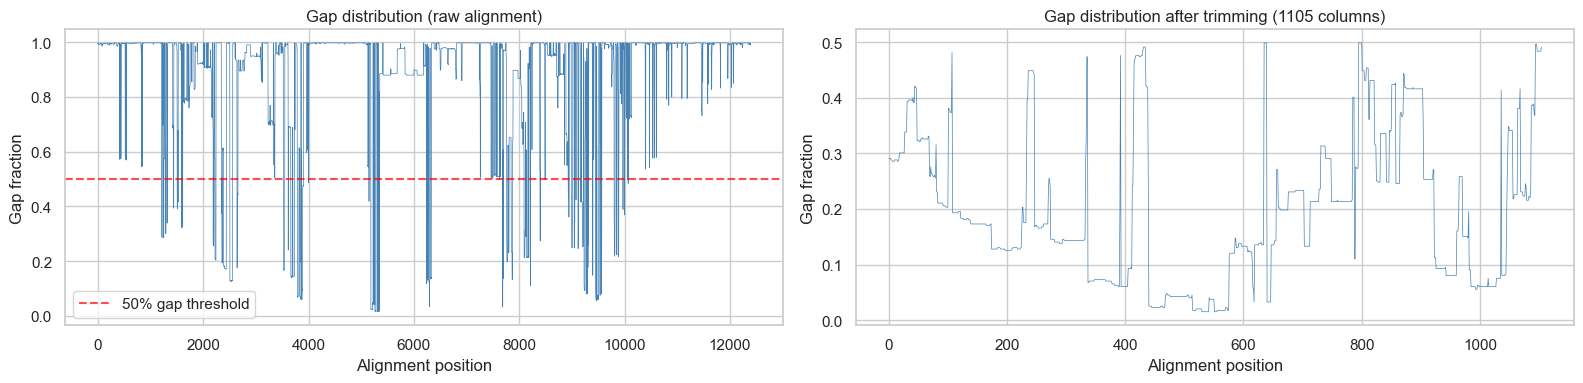

Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/alignment_gap_distribution.png


In [13]:
# ── Figure 6: Gap distribution + trimming ──
trimmed_path = DATA_PROC / f'{prefix}_aligned_trimmed.fasta'

if has_tblastn and n_seqs > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(gap_fracs, color='steelblue', linewidth=0.5)
    axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% gap threshold')
    axes[0].set_xlabel('Alignment position')
    axes[0].set_ylabel('Gap fraction')
    axes[0].set_title('Gap distribution (raw alignment)')
    axes[0].legend()

    # Trim columns with >50% gaps
    keep_cols = np.where(gap_fracs <= 0.5)[0]
    trimmed_records = []
    for record in alignment:
        trimmed_seq = ''.join(str(record.seq)[i] for i in keep_cols)
        trimmed_records.append(SeqRecord(Seq(trimmed_seq), id=record.id, description=''))

    SeqIO.write(trimmed_records, trimmed_path, 'fasta')
    n_codons = len(keep_cols) // 3
    print(f"Trimmed alignment: {len(trimmed_records)} sequences x {len(keep_cols)} columns ({n_codons} codons)")

    # Plot trimmed gaps
    trimmed_aln = AlignIO.read(trimmed_path, 'fasta')
    gap_fracs_trim = np.array([
        trimmed_aln[:, i].count('-') / len(trimmed_aln)
        for i in range(trimmed_aln.get_alignment_length())
    ])
    axes[1].plot(gap_fracs_trim, color='steelblue', linewidth=0.5)
    axes[1].set_xlabel('Alignment position')
    axes[1].set_ylabel('Gap fraction')
    axes[1].set_title(f'Gap distribution after trimming ({len(keep_cols)} columns)')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'alignment_gap_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / 'alignment_gap_distribution.png'}")
else:
    trimmed_records = []
    keep_cols = []
    n_codons = 0
    print("No alignment to trim")

## Summary

In [14]:
chr_anc = gu_filtered[gu_filtered['chrom'] == cfg['ancestral_chromosome']]
derived_out = gu_filtered[gu_filtered['chrom'] != cfg['ancestral_chromosome']]

## Summary

In [15]:
print("\n" + "=" * 70)
print("  DATA PREPARATION SUMMARY (Exon 4-15 Strategy)")


  DATA PREPARATION SUMMARY (Exon 4-15 Strategy)


## Summary

In [16]:
print("=" * 70)
print(f"  DATA PREPARATION SUMMARY — {GENE} in {SPECIES}")
print("=" * 70)
print(f"  Exon 13 anchors:           {len(exon13)}")
if has_tblastn:
    print(f"  Combined tBLASTn hits:     {len(tblastn)}")
print(f"  Gene units (all):          {len(gu_all)}")
if has_tblastn:
    print(f"  Coverage filter:           >= {MIN_COVERAGE*100:.0f}%")
    print(f"  Gene units (filtered):     {len(gu_filtered)}")
print(f"    Chr {cfg['ancestral_chromosome']} (ancestral):     {len(chr_anc)}")
for cls in sorted(gu_filtered['chrom_class'].unique()):
    if 'ancestral' not in cls:
        print(f"    {cls}: {len(gu_filtered[gu_filtered['chrom_class']==cls])}")
if n_seqs > 0:
    print(f"  Alignment:                 {n_seqs} seqs x {len(keep_cols)} cols ({n_codons} codons)")
    print(f"  Expansion ratio:           {len(derived_out)/max(len(chr_anc),1):.1f}x")
if not has_tblastn:
    print(f"\n  *** NEXT: Provide tBLASTn alignment file to complete the pipeline.")
print(f"\n  => Proceed to Step 02")
print("=" * 70)

  DATA PREPARATION SUMMARY — MROH6 in Zebra finch
  Exon 13 anchors:           411
  Combined tBLASTn hits:     3471
  Gene units (all):          419
  Coverage filter:           >= 50%
  Gene units (filtered):     399
    Chr 7 (ancestral):     8
    macro_derived: 10
    micro_derived: 378
    sex_chrom: 3
  Alignment:                 399 seqs x 1105 cols (368 codons)
  Expansion ratio:           48.9x

  => Proceed to Step 02


## Summary

In [17]:
print("=" * 70)